# Function 3 Analysis - Week 1

This notebook contains the exploratory analysis for **Function 3** in Week 1. We examine the initial datapoints to understand the relationship between inputs (x1, x2, x3) and the output (y), then use Bayesian optimization to find promising regions for further exploration.

**Function Description:** 	
You’re working on a drug discovery project, testing combinations of three compounds to create a new medicine. Each experiment is stored in initial_inputs.npy as a 3D array, where each row lists the amounts of the three compounds used. After each experiment, you record the number of adverse reactions, stored in initial_outputs.npy as a 1D array. Your goal is to minimise side effects; in this competition, it is framed as maximisation by optimising a transformed output (e.g. the negative of side effects). 


## Loading and Displaying the Data

We load the initial inputs and outputs for function 3 and display them in a table format to inspect the raw data values. We note that all inputs seem to be standardised in [0,1]. It is surprising as we would expect relative composition to play a key role, and by standardising each feature individually, you lose a bit of information. We have one outlier associated with a very high x3 value, which could indicate a threshold of toxicity and harm was passed.  


In [2]:
from pathlib import Path
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
sns.set_theme(style="ticks", context="notebook")
path = Path("../../initial_data/function_3")
X = np.load(path / "initial_inputs.npy")
y = np.load(path / "initial_outputs.npy")
df = pd.DataFrame(X, columns=["x1", "x2", "x3"]); df["y"] = y
df


,x1,x2,x3,y
0,0.171525,0.343917,0.248737,-0.112122
1,0.242114,0.644074,0.272433,-0.087963
2,0.534906,0.398501,0.173389,-0.111415
3,0.492581,0.611593,0.340176,-0.034835
4,0.134622,0.219917,0.458206,-0.048008
5,0.345523,0.941360,0.269363,-0.110621
6,0.151837,0.439991,0.990882,-0.398926
7,0.645503,0.397143,0.919771,-0.113869
8,0.746912,0.284196,0.226300,-0.131461
9,0.170477,0.697032,0.149169,-0.094190


## Correlation Matrix

The correlation heatmap shows pairwise correlations between all variables (x1, x2, x3, and y). This helps identify linear relationships. We note a high correlation between x1 and x2. We will see later that there is a line of high output points when x1 and x2 are similar in magnitude. 


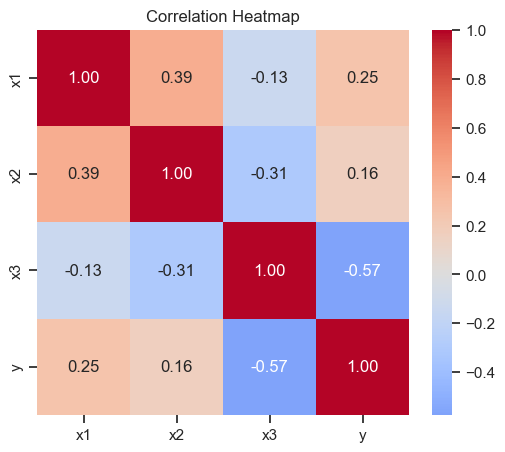

In [3]:
plt.figure(figsize=(6, 5))
sns.heatmap(df.corr(), cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()  

## Pairplot Analysis

The pairplot provides a comprehensive view of pairwise relationships between all variables (excluding datapoint 6 which is somewhat of an outlier and distorts the visual). The diagonal shows distributions (histograms), while off-diagonal plots show scatter plots. This helps identify patterns, clusters, and potential non-linear relationships that might not be captured by correlation alone.


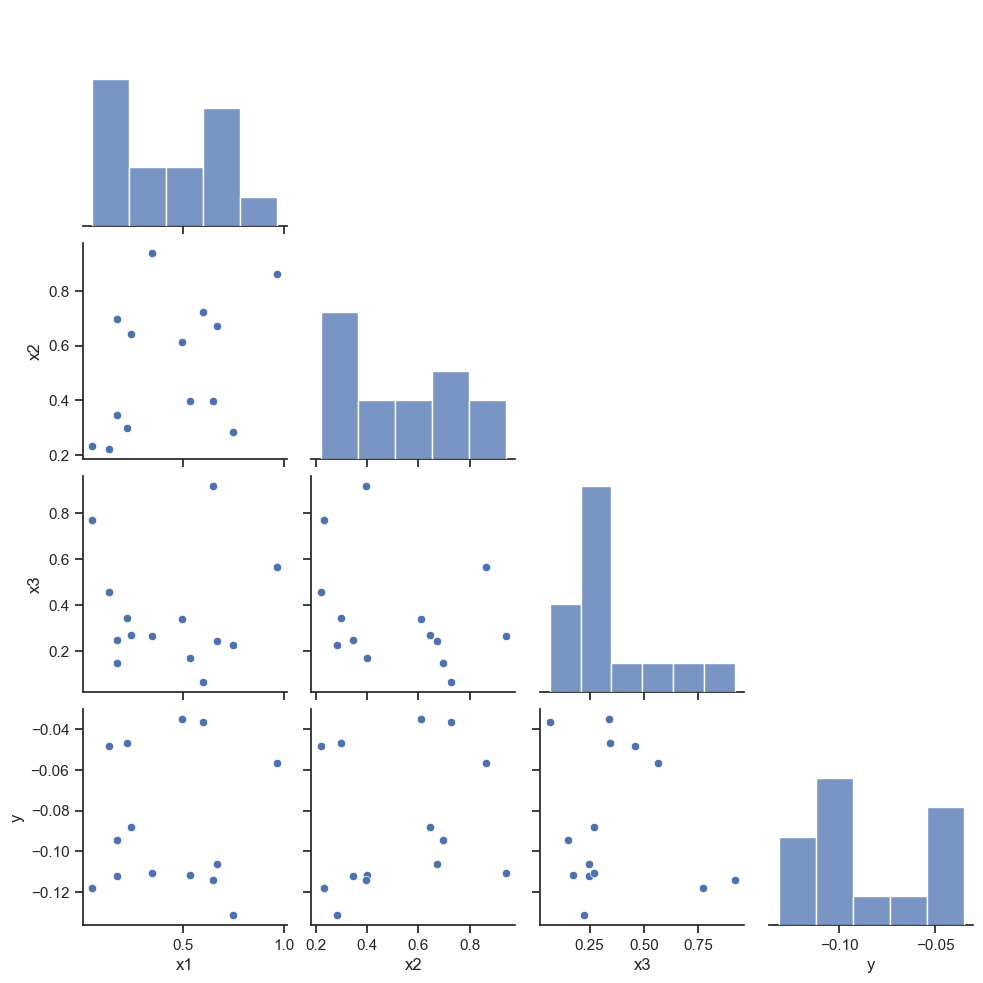

In [4]:
sns.pairplot(df.drop(index=6), corner=True, diag_kind="hist")
plt.show()


## Conclusion from Exploratory Analysis

From the correlation matrix and pairplot, we observe that there are no obvious strong linear correlations between the input variables and the output. This suggests the function has complex, non-linear relationships or interactions between the three compounds. Given this complexity, Bayesian optimization is well-suited as it can model non-linear relationships and balance exploration of unknown regions with exploitation of promising areas.


## Bayesian Optimization Setup

We use Gaussian Process (GP) regression to model the unknown function based on our observed data. The GP provides both a mean prediction and uncertainty estimates. We use the Upper Confidence Bound (UCB) acquisition function to balance exploration (high uncertainty) and exploitation (high predicted mean). The search space is defined as [0, 1] for each of the three input variables.


In [5]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern
from scipy.optimize import minimize
np.random.seed(42)
kernel = Matern(length_scale=1.0, nu=2.5)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6, normalize_y=True, n_restarts_optimizer=5)
gp.fit(X, y)
print("GP fitted successfully")


GP fitted successfully


## Finding the Next Point to Evaluate

We optimize the Upper Confidence Bound (UCB) acquisition function: UCB(x) = μ(x) + κ·σ(x), where μ(x) is the predicted mean, σ(x) is the predicted standard deviation, and κ is a parameter controlling the exploration-exploitation trade-off. A higher κ favors exploration, while a lower κ favors exploitation. We use κ=2.0 to balance both objectives.


In [6]:
kappa = 2.0
def ucb(x):
    x = x.reshape(1, -1)
    mu, sigma = gp.predict(x, return_std=True)
    return -(mu + kappa * sigma)
bounds = [(0, 1), (0, 1), (0, 1)]
result = minimize(ucb, x0=np.random.uniform(0, 1, 3), bounds=bounds, method='L-BFGS-B')
next_point = result.x
mu_pred, sigma_pred = gp.predict(next_point.reshape(1, -1), return_std=True)
print(f"Next point to evaluate: x1={next_point[0]:.4f}, x2={next_point[1]:.4f}, x3={next_point[2]:.4f}")
print(f"Predicted output: {mu_pred[0]:.4f} ± {sigma_pred[0]:.4f}")
print(f"UCB value: {mu_pred[0] + kappa * sigma_pred[0]:.4f}")


Next point to evaluate: x1=0.4035, x2=0.3822, x3=0.4894
Predicted output: -0.0589 ± 0.0706
UCB value: 0.0822


## Visualization of Recommended Point

We visualize the recommended point in the input space alongside the existing observations. This helps understand where the Bayesian optimization suggests exploring next relative to our current data. 


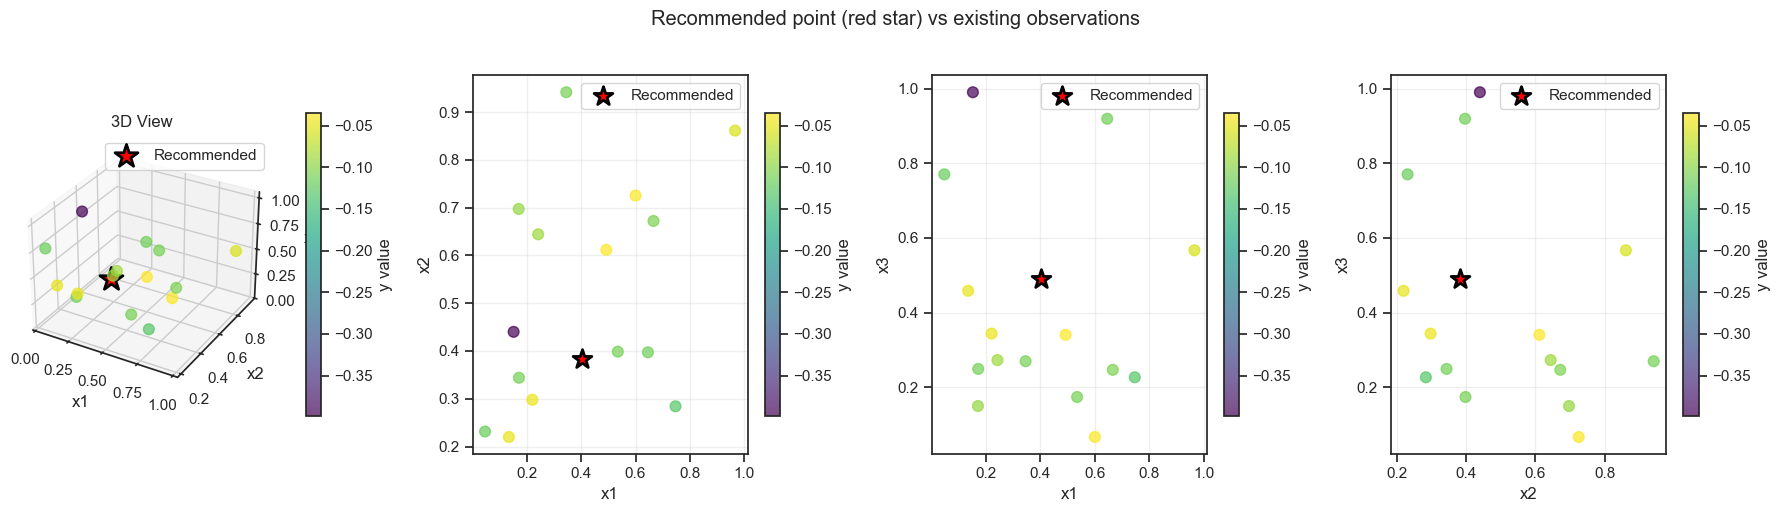

In [7]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(18, 5))
ax_3d = fig.add_subplot(141, projection='3d')
scatter_3d = ax_3d.scatter(X[:, 0], X[:, 1], X[:, 2], c=y, cmap="viridis", s=60, alpha=0.7)
ax_3d.scatter(next_point[0], next_point[1], next_point[2], c="red", s=300, marker="*", edgecolors="black", linewidths=2, label="Recommended")
ax_3d.set_xlabel("x1")
ax_3d.set_ylabel("x2")
ax_3d.set_zlabel("x3")
ax_3d.legend()
ax_3d.set_title("3D View")
fig.colorbar(scatter_3d, ax=ax_3d, label="y value", shrink=0.8, pad=0.1)
axes = [fig.add_subplot(142), fig.add_subplot(143), fig.add_subplot(144)]
pairs = [(0, 1, "x1", "x2"), (0, 2, "x1", "x3"), (1, 2, "x2", "x3")]
for idx, (i, j, label_i, label_j) in enumerate(pairs):
    scatter2d = axes[idx].scatter(X[:, i], X[:, j], c=y, cmap="viridis", s=60, alpha=0.7)
    axes[idx].scatter(next_point[i], next_point[j], c="red", s=200, marker="*", edgecolors="black", linewidths=2, label="Recommended")
    axes[idx].set_xlabel(label_i)
    axes[idx].set_ylabel(label_j)
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)
    plt.colorbar(scatter2d, ax=axes[idx], label="y value", shrink=0.8)
plt.suptitle("Recommended point (red star) vs existing observations", y=1.02)
plt.tight_layout()
plt.show()


## Analysis and recommendation

From the correlation matrix and pairplot, we observe that there are no obvious strong linear correlations between the input variables and the output. This suggests the function has complex, non-linear relationships or interactions between the three compounds. Given this complexity, Bayesian optimization is well-suited as it can model non-linear relationships and balance exploration of unknown regions with exploitation of promising areas. The Bayesian optimisation picked a very interesting recommended point with coordinates: x1=0.4035, x2=0.3822, x3=0.4894. It is interesting because when looking at the 5 highest outputs, all of them have a x1 and x2 values in a similar order of magnitude and four out of five have x3  between 0.35 and 0.6. The new point confirms these features while filling some white space on each of the axes.